In [1]:
import os
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.applications import inception_v3 as inc_net
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
%matplotlib inline
keras.__version__

'3.9.0'

In [3]:
inet_model = inc_net.InceptionV3()
inet_model

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 222s 2us/step


<Functional name=inception_v3, built=True>

In [4]:
def transform_img_fn(path_list):
    out = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = inc_net.preprocess_input(x)
        out.append(x)
    return np.vstack(out)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.100000024..1.1].


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
('n02504458', 'African_elephant', 0.17037612)
('n02408429', 'water_buffalo', 0.06658406)
('n02412080', 'ram', 0.04596967)
('n02111129', 'Leonberg', 0.041582372)
('n02415577', 'bighorn', 0.04107347)


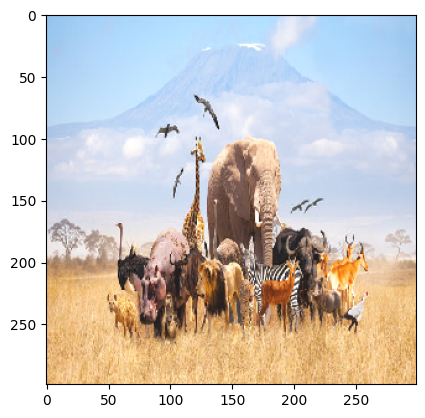

In [47]:
img = transform_img_fn(['images/animals.jpg'])
plt.imshow(img[0] / 2 + 0.6)
# preds = inet_model.predict(img)
preds = inet_model.predict(img)
for x in decode_predictions(preds)[0]:
    print(x)

In [48]:
from lime import lime_image

explainer = lime_image.LimeImageExplainer()

In [49]:
%%time 

explanation = explainer.explain_instance(img[0].astype('double'), inet_model.predict, top_labels=5, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 

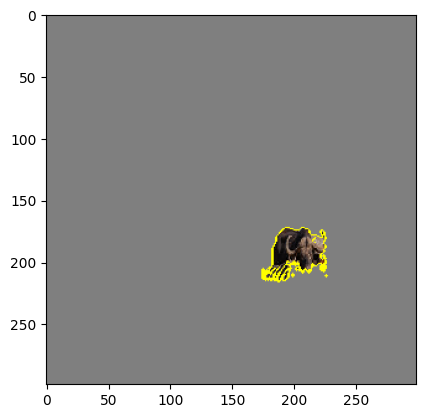

In [67]:
from skimage.segmentation import mark_boundaries

temp, mask = explanation.get_image_and_mask(explanation.top_labels[1], positive_only=True, num_features=1, hide_rest=True)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

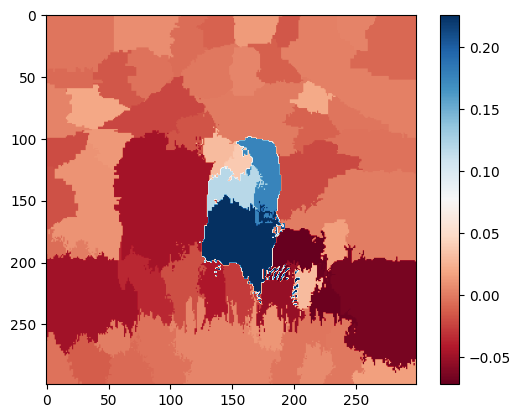

In [61]:
ind = explanation.top_labels[0]
dict_heatmap = dict(explanation.local_exp[ind])
heatmap = np.vectorize(dict_heatmap.get)(explanation.segments)

plt.imshow(heatmap, cmap='RdBu', vmin=heatmap.min(), vmax=heatmap.max())
plt.colorbar()

In [68]:
explanation.local_exp

{349: [(40, -0.011220902699323474),
  (36, -0.010418454972320508),
  (59, 0.009941354781359497),
  (53, 0.008669461958783133),
  (33, 0.008351811895835967),
  (49, -0.007943236469194866),
  (60, 0.0076351747197549),
  (41, -0.007425409782409422),
  (47, 0.0066635053506676305),
  (45, 0.005636861085580911),
  (24, 0.005461044666456057),
  (42, 0.005297995709687193),
  (8, -0.004838709002424497),
  (22, -0.004569553897705617),
  (0, 0.00430980049833675),
  (57, 0.004248771210118589),
  (50, 0.0040546979660613155),
  (10, -0.003973260248026833),
  (5, -0.0038515774737747036),
  (52, 0.003407043629181245),
  (26, 0.0033956640566169412),
  (12, -0.0031658753152146906),
  (23, 0.0030991675576255025),
  (51, -0.003025119814317137),
  (37, 0.0028902088366784475),
  (28, -0.002806137688322387),
  (9, 0.0027974856512164403),
  (2, 0.0026907802027386673),
  (20, -0.002659007946570454),
  (39, 0.002586098896168315),
  (30, -0.0025727277917622533),
  (44, 0.002446735891749246),
  (56, 0.00244627980